# PCA, Variance Threshold, and Categorical Feature Selection  
**Assignment:** PCA/Variance Threshold (Regression) + χ² Feature Selection (Classification)  
**Student:** Adjovi Gloria  
**Datasets:** House Prices (train.csv), Mushroom Classification (mushrooms.csv)

> This notebook follows the instructions exactly:  
> - Fit preprocessing steps on the training set only  
> - Transform the test set using the already-fitted objects (no data leakage)


## Part 1 — PCA and Variance Threshold in a Linear Regression (House Prices)

### Goals
- Clean and prepare the Kaggle **House Prices** training data
- Build a **baseline linear regression**
- Compare baseline results against:
  1) **PCA** retaining 90% variance  
  2) **MinMax scaling + VarianceThreshold (> 0.1)**

### Notes on decisions
- Columns missing more than **40%** are dropped to avoid imputing too much missing information.
- Numeric imputation uses **median** (robust to outliers).
- Categorical imputation uses **mode** (most common category).
- Categorical variables are converted to **dummy variables** (one-hot encoding).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

#I Put train.csv and mushrooms.csv in the SAME folder as this notebook
HOUSE_PATH = "train.csv"
MUSHROOM_PATH = "mushrooms.csv"




In [4]:
# Step 1–6: Load, drop columns, impute, dummy variables, split
df = pd.read_csv(HOUSE_PATH)
target = "SalePrice"

print("Loaded House Prices data:", df.shape)
print("Target column present?", target in df.columns)

# Step 2: Drop Id and any features missing > 40%
df = df.drop(columns=["Id"], errors="ignore")

X = df.drop(columns=[target])
y = df[target]

missing_frac = X.isna().mean()
cols_to_drop = missing_frac[missing_frac > 0.40].index.tolist()
X = X.drop(columns=cols_to_drop, errors="ignore")

print(f"Columns dropped for >40% missing: {len(cols_to_drop)}")
print("Remaining features (before encoding):", X.shape[1])

# Step 3–4: Impute numeric with median, categorical with mode
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())

for c in cat_cols:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].mode(dropna=True)[0])

# Step 5: Convert categoricals to dummy variables
X = pd.get_dummies(X, drop_first=False)

print("Feature count after dummy variables:", X.shape[1])
print("Any missing values left?", X.isna().any().any())

# Step 6: Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Loaded House Prices data: (1460, 81)
Target column present? True
Columns dropped for >40% missing: 6
Remaining features (before encoding): 73
Feature count after dummy variables: 266
Any missing values left? False
Train shape: (1168, 266)  Test shape: (292, 266)


In [5]:
# Step 7: Baseline Linear Regression (all features)
def eval_linreg(Xtr, Xte, ytr, yte):
    model = LinearRegression()
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    r2 = r2_score(yte, preds)
    rmse = np.sqrt(mean_squared_error(yte, preds))  # RMSE for older sklearn
    return r2, rmse

baseline_r2, baseline_rmse = eval_linreg(X_train, X_test, y_train, y_test)

print("Baseline Linear Regression")
print(f"R²:   {baseline_r2:.4f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print("Baseline feature count:", X_train.shape[1])



Baseline Linear Regression
R²:   0.8852
RMSE: 29,679.51
Baseline feature count: 266


In [6]:
# ---------------------------
# Step 8–10: PCA retaining 90% variance (fit on train, transform test)
# ---------------------------
pca = PCA(n_components=0.90, random_state=42)

X_train_pca = pca.fit_transform(X_train)   # fit + transform train
X_test_pca = pca.transform(X_test)         # transform test ONLY

print("PCA components used to retain 90% variance:", pca.n_components_)
print("PCA train shape:", X_train_pca.shape, " PCA test shape:", X_test_pca.shape)

pca_r2, pca_rmse = eval_linreg(X_train_pca, X_test_pca, y_train, y_test)

print("\nLinear Regression after PCA (90% variance)")
print(f"R²:   {pca_r2:.4f}")
print(f"RMSE: {pca_rmse:,.2f}")


PCA components used to retain 90% variance: 1
PCA train shape: (1168, 1)  PCA test shape: (292, 1)

Linear Regression after PCA (90% variance)
R²:   0.0635
RMSE: 84,754.58


In [7]:
# ---------------------------
# Step 11–13: MinMax scaling + VarianceThreshold > 0.1 (fit on train, transform test)
# ---------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

vt = VarianceThreshold(threshold=0.1)
X_train_highvar = vt.fit_transform(X_train_scaled)
X_test_highvar = vt.transform(X_test_scaled)

print("High-variance feature count (variance > 0.1):", X_train_highvar.shape[1])

highvar_r2, highvar_rmse = eval_linreg(X_train_highvar, X_test_highvar, y_train, y_test)

print("\nLinear Regression after MinMax + VarianceThreshold (>0.1)")
print(f"R²:   {highvar_r2:.4f}")
print(f"RMSE: {highvar_rmse:,.2f}")


High-variance feature count (variance > 0.1): 47

Linear Regression after MinMax + VarianceThreshold (>0.1)
R²:   0.6640
RMSE: 50,765.87


In [8]:
# ---------------------------
# Step 14: Summarize findings (table)
# ---------------------------
summary_part1 = pd.DataFrame({
    "Model": [
        "Baseline Linear Regression (all features)",
        "Linear Regression + PCA (90% variance)",
        "Linear Regression + MinMax + VarianceThreshold (>0.1)"
    ],
    "R2": [baseline_r2, pca_r2, highvar_r2],
    "RMSE": [baseline_rmse, pca_rmse, highvar_rmse],
    "Feature_Count": [X_train.shape[1], pca.n_components_, X_train_highvar.shape[1]]
})

summary_part1


,Model,R2,RMSE,Feature_Count
0,Baseline Linear Regression (all features),0.885158,29679.512573,266
1,Linear Regression + PCA (90% variance),0.063490,84754.580209,1
2,Linear Regression + MinMax + VarianceThreshold...,0.664007,50765.865533,47


## Part 2 — Categorical Feature Selection (Mushrooms)

### Goals
- Convert all categorical features to dummy variables
- Train a **Decision Tree Classifier**
- Report **accuracy** + **confusion matrix**
- Visualize the decision tree
- Use **χ² SelectKBest (k=5)** to select top features
- Re-train the model using only those 5 features and compare results


In [9]:
# ---------------------------
# Step 1–3: Load, dummy variables, split
# ---------------------------
df_m = pd.read_csv(MUSHROOM_PATH)
print("Loaded Mushroom data:", df_m.shape)

if "class" not in df_m.columns:
    raise ValueError("Expected a 'class' column (target). Please verify your mushrooms.csv file.")

y_m = df_m["class"]
X_m = df_m.drop(columns=["class"])

# Step 2: dummies
X_m = pd.get_dummies(X_m, drop_first=False)
print("Mushroom feature count after dummies:", X_m.shape[1])

# Step 3: split (stratify to preserve class balance)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.20, random_state=42, stratify=y_m
)

print("Train:", X_train_m.shape, " Test:", X_test_m.shape)


Loaded Mushroom data: (8124, 23)
Mushroom feature count after dummies: 117
Train: (6499, 117)  Test: (1625, 117)


Decision Tree (all features)
Accuracy: 1.0000


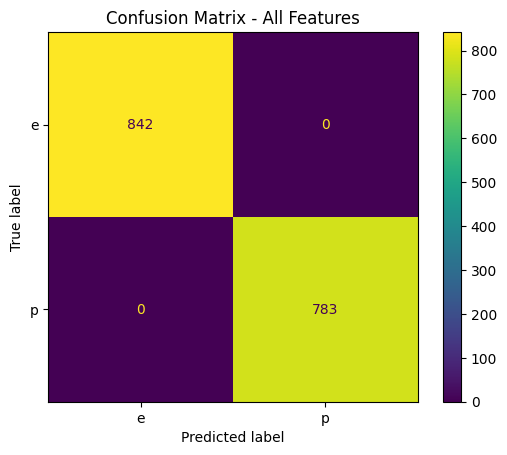

In [10]:
# ---------------------------
# Step 4–5: Fit decision tree, report accuracy + confusion matrix
# ---------------------------
clf_all = DecisionTreeClassifier(random_state=42)
clf_all.fit(X_train_m, y_train_m)

pred_all = clf_all.predict(X_test_m)
acc_all = accuracy_score(y_test_m, pred_all)

cm_all = confusion_matrix(y_test_m, pred_all, labels=clf_all.classes_)

print("Decision Tree (all features)")
print(f"Accuracy: {acc_all:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=clf_all.classes_)
disp.plot()
plt.title("Confusion Matrix - All Features")
plt.show()


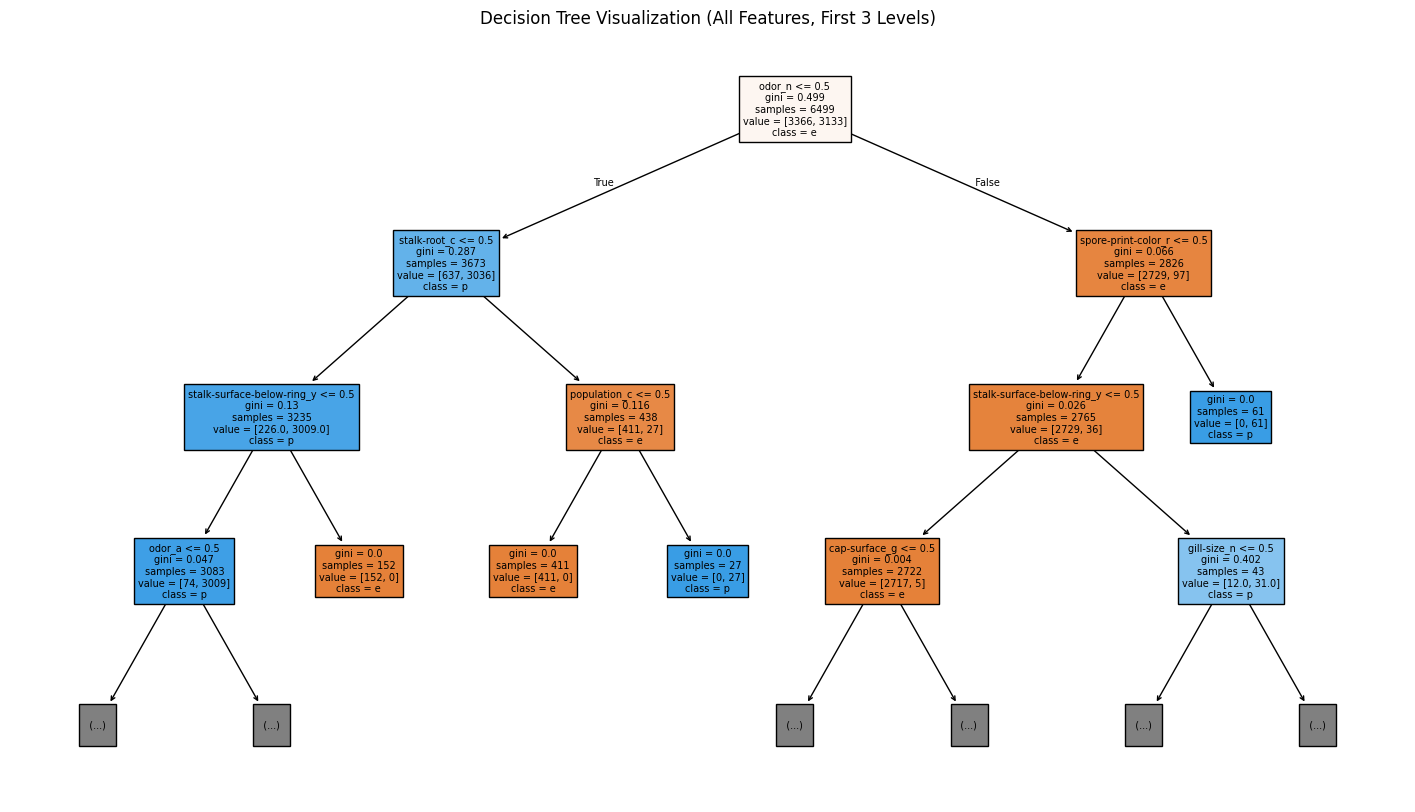

In [11]:
# ---------------------------
# Step 6: Visualize decision tree (limited depth so it's readable)
# ---------------------------
plt.figure(figsize=(18, 10))
plot_tree(
    clf_all,
    feature_names=X_m.columns,
    class_names=clf_all.classes_,
    filled=True,
    max_depth=3
)
plt.title("Decision Tree Visualization (All Features, First 3 Levels)")
plt.show()


In [12]:
# ---------------------------
# Step 7–8: χ² SelectKBest (k=5) and show selected features
# ---------------------------
selector = SelectKBest(score_func=chi2, k=5)
X_train_k = selector.fit_transform(X_train_m, y_train_m)
X_test_k = selector.transform(X_test_m)

selected_mask = selector.get_support()
selected_features = X_m.columns[selected_mask].tolist()

print("Top 5 χ²-selected features:")
for f in selected_features:
    print(" -", f)


Top 5 χ²-selected features:
 - odor_f
 - odor_n
 - gill-color_b
 - stalk-surface-above-ring_k
 - stalk-surface-below-ring_k



Decision Tree (Top 5 χ² features)
Accuracy: 0.9243


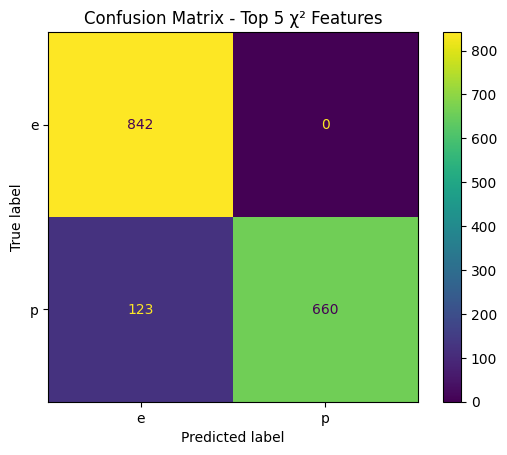

In [13]:
# ---------------------------
# Step 9: Refit decision tree using only the 5 selected features
# ---------------------------
clf_k = DecisionTreeClassifier(random_state=42)
clf_k.fit(X_train_k, y_train_m)

pred_k = clf_k.predict(X_test_k)
acc_k = accuracy_score(y_test_m, pred_k)

cm_k = confusion_matrix(y_test_m, pred_k, labels=clf_k.classes_)

print("\nDecision Tree (Top 5 χ² features)")
print(f"Accuracy: {acc_k:.4f}")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_k, display_labels=clf_k.classes_)
disp2.plot()
plt.title("Confusion Matrix - Top 5 χ² Features")
plt.show()


In [14]:
# ---------------------------
# Step 10: Summarize findings (table)
# ---------------------------
summary_part2 = pd.DataFrame({
    "Model": ["Decision Tree (all features)", "Decision Tree (χ² top-5 features)"],
    "Accuracy": [acc_all, acc_k],
    "Feature_Count": [X_m.shape[1], 5]
})
summary_part2


,Model,Accuracy,Feature_Count
0,Decision Tree (all features),1.000000,117
1,Decision Tree (χ² top-5 features),0.924308,5


## Final Findings 

### Part 1 (House Prices)
- I Compare the baseline against PCA and variance-threshold approaches.
- I Note that PCA can heavily compress the feature space; if performance drops, explain why.
- I Explain the trade-off between **fewer features** vs **predictive performance**.

### Part 2 (Mushrooms)
- Decision trees can achieve extremely high accuracy on this dataset.
- χ² feature selection shows that **a small set of categorical indicators** can still predict well,
  but may lose some accuracy compared to using all features.

### Data Sources
- House Prices — Advanced Regression Techniques (Kaggle): train.csv  
- Mushroom Classification (Kaggle / UCI-style dataset): mushrooms.csv
